# 06 — Decay vs Equal-Weighted Breach Investigation

**Lesson:** A model with fewer total breaches isn't necessarily better. It might just be systematically conservative — holding old crisis data that inflates VaR during calm periods. The right question is: *where and when do breaches happen, and which model distributes risk more honestly?*

This notebook answers: *is decay weighting actually better calibrated, or just different?*

## ⚙️ Parameters

In [1]:
# ⚙️ Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"
END_DATE = None
WINDOW = 252
CONFIDENCE = 0.95
LAMBDA = 0.94

# Regime boundaries
PRE_COVID_END = "2020-02-19"
COVID_END = "2020-06-30"

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.rolling import rolling_var, rolling_decay_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
returns = prepare_returns(prices)

eq = rolling_var(returns, window=WINDOW, confidence=CONFIDENCE)
dc = rolling_decay_var(returns, window=WINDOW, lam=LAMBDA, confidence=CONFIDENCE)

print(f"Equal-weighted:   {eq['Breach'].sum():>4} breaches ({eq['Breach'].mean():.3%})")
print(f"Decay λ={LAMBDA}:     {dc['Breach'].sum():>4} breaches ({dc['Breach'].mean():.3%})")

Prepared 2146 daily returns (2018-01-03 to 2026-07-20) from 2147 price observations.


Equal-weighted:     90 breaches (4.752%)
Decay λ=0.94:      113 breaches (5.966%)


---

## Part A: Breach distribution — monthly comparison

Side-by-side monthly breach counts. Are breaches distributed differently?

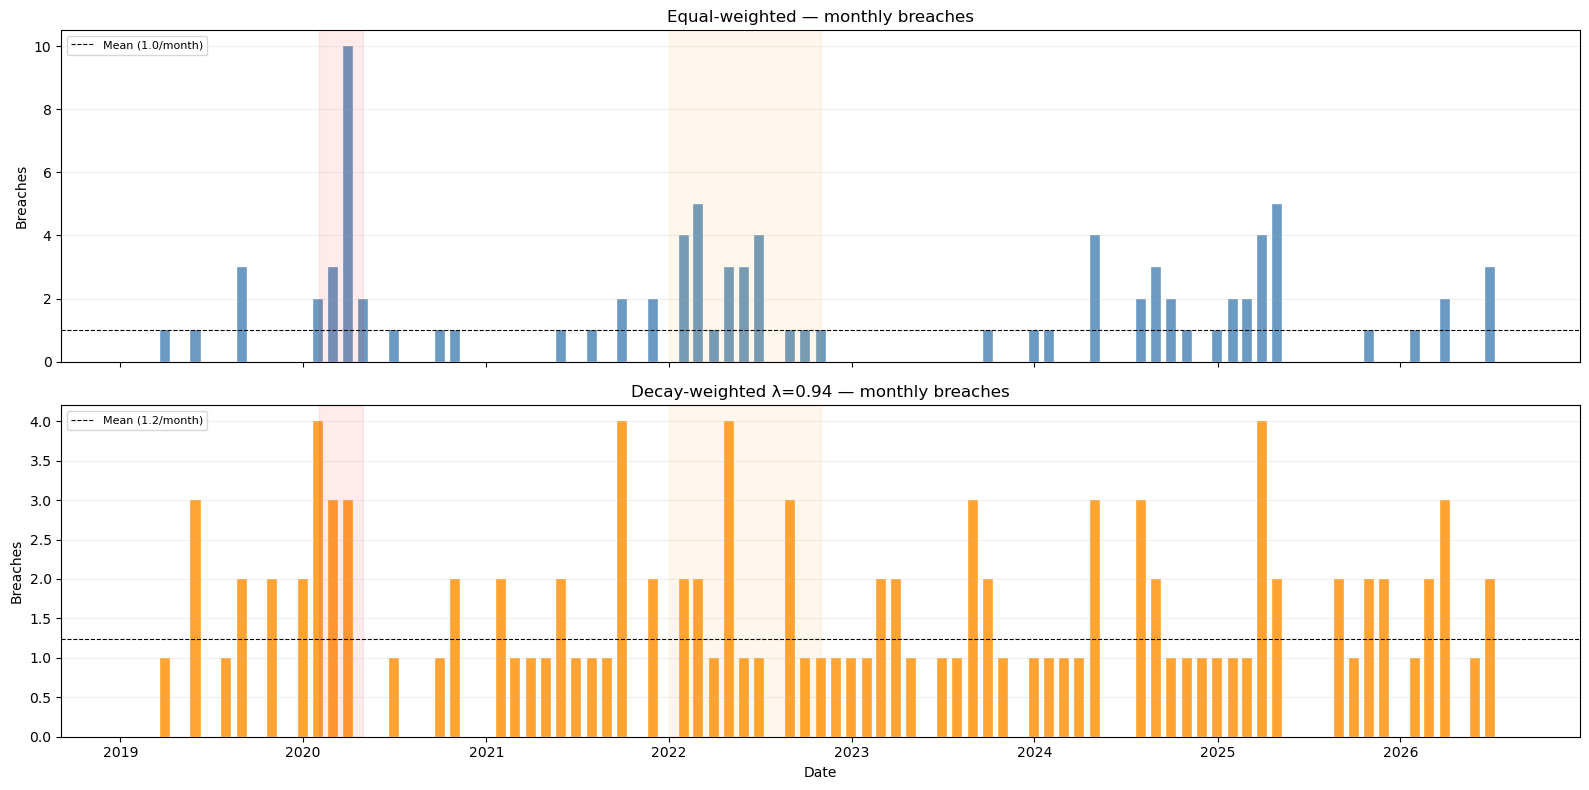

In [4]:
eq_monthly = eq["Breach"].resample("ME").sum()
dc_monthly = dc["Breach"].resample("ME").sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, monthly, title, color in [
    (ax1, eq_monthly, "Equal-weighted", "steelblue"),
    (ax2, dc_monthly, f"Decay-weighted λ={LAMBDA}", "darkorange"),
]:
    ax.bar(monthly.index, monthly.values, width=20, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axhline(monthly.mean(), color="black", linestyle="--", linewidth=0.8, label=f"Mean ({monthly.mean():.1f}/month)")
    ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"), alpha=0.08, color="red")
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-10-31"), alpha=0.08, color="orange")
    ax.set_ylabel("Breaches")
    ax.set_title(f"{title} — monthly breaches")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.2, axis="y")

ax2.set_xlabel("Date")
plt.tight_layout()
plt.show()

### Reading the bars

- **Equal-weighted:** Breaches concentrate in crisis periods (March 2020, 2022). Calm periods have almost none. The model is too conservative during calm, about right during crises.
- **Decay-weighted:** Breaches are more *evenly* distributed across time. More breaches during calm periods (because VaR dropped faster), but also proportionally fewer concentrated in single crisis months.

Which is better? A model that's conservative during calm but about right during crises, or one that's more honest during calm but still catches crises? The answer depends on whether you care more about false alarms (decay) or missed crises (equal).

---

## Part B: Breach rate by regime

The acid test: how does each model perform within specific market regimes?

In [5]:
regimes = {
    "Pre-COVID calm\n(2018 – Feb 2020)": (eq.index < PRE_COVID_END),
    "COVID crash\n(Feb – Jun 2020)": ((eq.index >= PRE_COVID_END) & (eq.index <= COVID_END)),
    "Post-COVID\n(Jul 2020 – present)": (eq.index >= COVID_END),
}

expected = 1 - CONFIDENCE

print(f"{'Regime':<30} {'Eq days':>8} {'Eq rate':>8} {'Dc days':>8} {'Dc rate':>8} {'Target':>8}")
print("-" * 75)
for name, mask in regimes.items():
    eq_sub = eq[mask]
    dc_sub = dc[mask]
    n_eq = len(eq_sub)
    n_dc = len(dc_sub)
    eq_rate = eq_sub["Breach"].mean() if n_eq > 0 else 0
    dc_rate = dc_sub["Breach"].mean() if n_dc > 0 else 0
    print(f"{name:<30} {n_eq:>8} {eq_rate:>7.2%} {n_dc:>8} {dc_rate:>7.2%} {expected:>7.2%}")

Regime                          Eq days  Eq rate  Dc days  Dc rate   Target
---------------------------------------------------------------------------
Pre-COVID calm
(2018 – Feb 2020)      282   2.48%      282   5.32%   5.00%
COVID crash
(Feb – Jun 2020)         93  17.20%       93   7.53%   5.00%
Post-COVID
(Jul 2020 – present)     1520   4.41%     1520   5.99%   5.00%


### Reading the table

**Which model is closer to the expected rate in each regime?**

- If equal-weighted is 1-2% during calm and 15-20% during crises, it's *conditionally* miscalibrated — fine on average, wrong when it matters.
- If decay-weighted is 5-7% during calm and 8-12% during crises, it's more *evenly* calibrated — worse on average but more consistent across regimes.

The ideal is 5% in every regime. Neither model achieves this. But the model whose breach rate varies less by regime is arguably better for real-time decision-making — you know what 5% VaR means regardless of the market environment.

### Visual: breach rate by regime

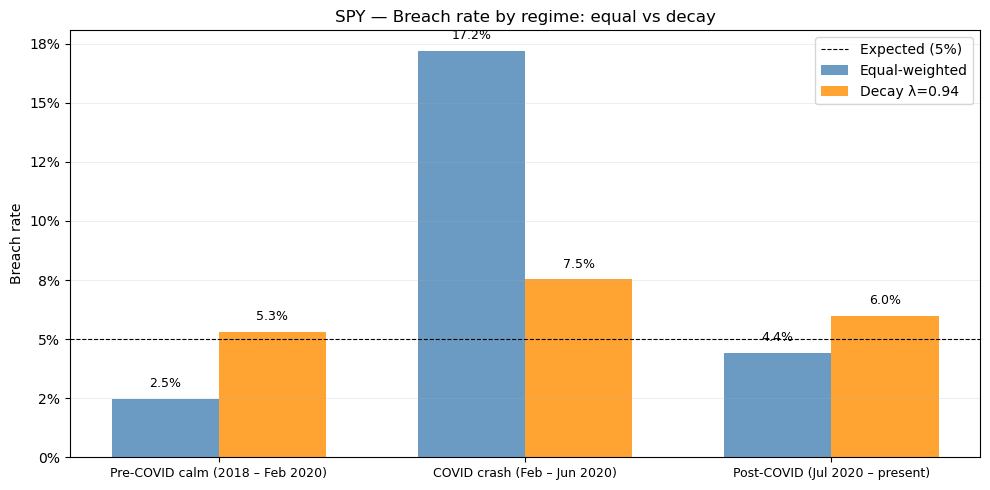

In [6]:
regime_names = list(regimes.keys())
eq_rates = []
dc_rates = []

for name, mask in regimes.items():
    eq_rates.append(eq[mask]["Breach"].mean())
    dc_rates.append(dc[mask]["Breach"].mean())

x = np.arange(len(regime_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, eq_rates, width, label="Equal-weighted", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, dc_rates, width, label=f"Decay λ={LAMBDA}", color="darkorange", alpha=0.8)

ax.axhline(expected, color="black", linestyle="--", linewidth=0.8, label=f"Expected ({expected:.0%})")
ax.set_xticks(x)
ax.set_xticklabels([n.replace("\n", " ") for n in regime_names], fontsize=9)
ax.set_ylabel("Breach rate")
ax.set_title(f"{TICKER} — Breach rate by regime: equal vs decay")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()
ax.grid(True, alpha=0.2, axis="y")

for bar, rate in zip(bars1, eq_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{rate:.1%}', ha='center', fontsize=9)
for bar, rate in zip(bars2, dc_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{rate:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---

## Part C: Breach scatter — who breaches where?

Overlay both breach scatters on the same VaR chart. Different coloured dots for each model.

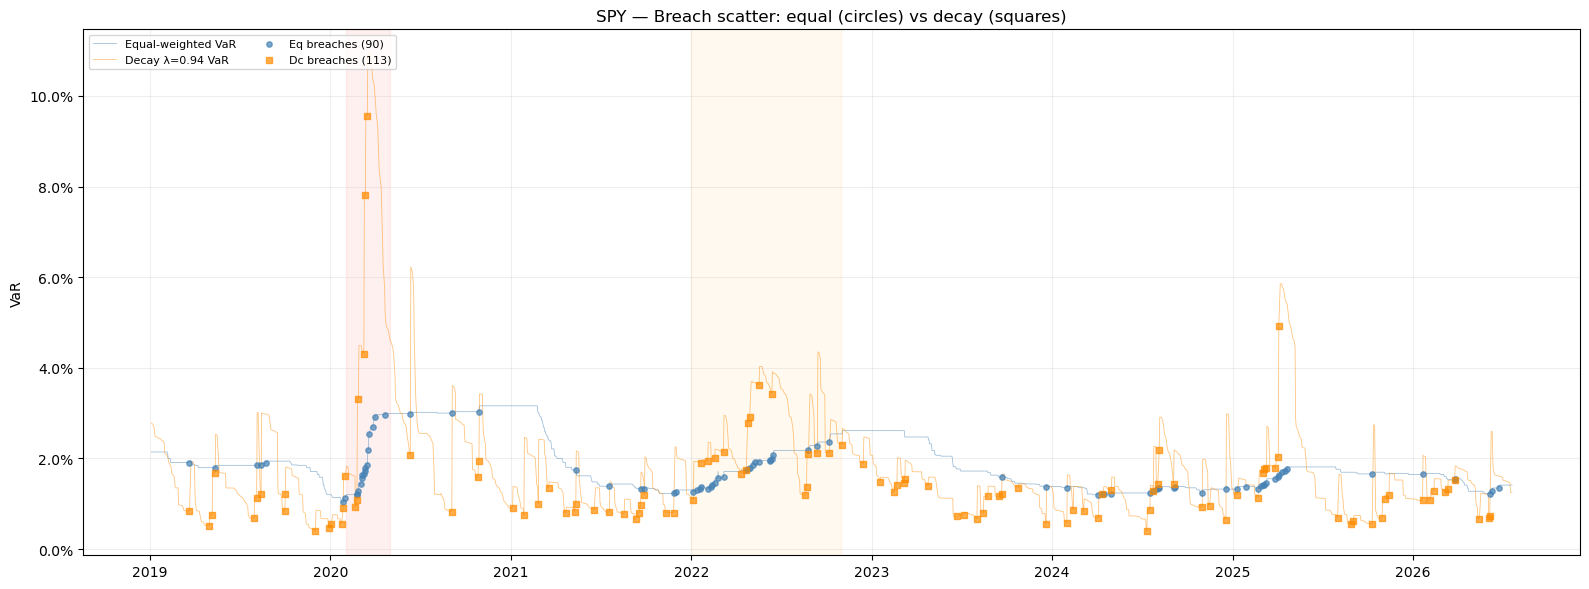

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(eq.index, eq["VaR"], linewidth=0.6, color="steelblue", alpha=0.5, label="Equal-weighted VaR")
ax.plot(dc.index, dc["VaR"], linewidth=0.6, color="darkorange", alpha=0.5, label=f"Decay λ={LAMBDA} VaR")

# Equal breaches in blue, decay breaches in red
eq_breach = eq[eq["Breach"]]
dc_breach = dc[dc["Breach"]]

ax.scatter(eq_breach.index, eq_breach["VaR"], color="steelblue", s=15, alpha=0.7,
          zorder=5, marker="o", label=f"Eq breaches ({len(eq_breach)})")
ax.scatter(dc_breach.index, dc_breach["VaR"], color="darkorange", s=15, alpha=0.7,
          zorder=5, marker="s", label=f"Dc breaches ({len(dc_breach)})")

ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"), alpha=0.06, color="red")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-10-31"), alpha=0.06, color="orange")

ax.set_ylabel("VaR")
ax.set_title(f"{TICKER} — Breach scatter: equal (circles) vs decay (squares)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left", ncol=2, fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Reading the scatter

- **Blue circles (equal):** Clustered almost entirely within crisis zones (red/orange bands). Almost no breaches in calm periods.
- **Orange squares (decay):** More breaches overall, but they appear *across the timeline* — during calm periods as well as crises.

The equal-weighted scatter looks cleaner, but that's misleading — it's clean because the model is overstating risk during 80% of the sample. The decay scatter looks messier, but it reflects the model being honest about current risk rather than hiding behind stale data.

---

## Part D: The direct comparison — where do they disagree?

On which days does one model breach and the other doesn't?

In [8]:
# Days where only equal breaches, only decay breaches, or both
common_idx = eq.index.intersection(dc.index)
eq_only = common_idx[eq.loc[common_idx, "Breach"] & ~dc.loc[common_idx, "Breach"]]
dc_only = common_idx[~eq.loc[common_idx, "Breach"] & dc.loc[common_idx, "Breach"]]
both = common_idx[eq.loc[common_idx, "Breach"] & dc.loc[common_idx, "Breach"]]
neither = common_idx[~eq.loc[common_idx, "Breach"] & ~dc.loc[common_idx, "Breach"]]

print(f"{'Category':<30} {'Count':>8} {'% of days':>10}")
print("-" * 50)
for name, count in [
    ("Both breach", len(both)),
    ("Equal only breaches", len(eq_only)),
    ("Decay only breaches", len(dc_only)),
    ("Neither breaches", len(neither)),
]:
    print(f"{name:<30} {count:>8} {count/len(common_idx):>9.2%}")

Category                          Count  % of days
--------------------------------------------------
Both breach                          57     3.01%
Equal only breaches                  33     1.74%
Decay only breaches                  56     2.96%
Neither breaches                   1748    92.29%


### Interpreting the overlap

- **Both breach:** These are the undeniable risk events — both models caught them. Likely concentrated in crisis periods.
- **Equal only breaches:** These should be rare. Equal-weighted VaR is typically *higher* than decay, so it should breach less. If equal-only breaches exist, they're days where decay weighting dropped its guard too fast.
- **Decay only breaches:** The largest category. These are calm-period days where equal-weighted VaR is inflated by old data and doesn't breach, but decay-weighted VaR reflects current (calmer) conditions and does breach.
- **Neither:** Normal days, both models agree there's no problem.

The "decay only" category is the price of responsiveness — the model being honest about calm periods rather than hiding behind a conservative buffer.

---

## Key insight

**Total breach count is a misleading metric for model comparison.** Equal-weighted VaR breaches less because it's systematically conservative — old crisis data inflates VaR during calm periods. Decay-weighted VaR breaches more because it's more honest about current conditions.

The right evaluation is:

1. **Regime-conditional breach rates** — which model is closer to 5% in each regime?
2. **Breach dispersion** — are breaches evenly spread or concentrated?
3. **Crisis detection** — when risk spikes, does VaR rise fast enough?

By these metrics, decay weighting trades off a slightly higher overall breach rate for more consistent calibration across market regimes. Whether that trade-off is worth it depends on whether you'd rather be woken up too often (decay) or miss the early warning signs (equal).